# Assignment 1 — The Satellite Classifier

Run these cells top to bottom. By the **Submit** cell you will have a working
`submission.zip` that scores around 83% on the leaderboard.

This is the *warm-up* round. The goal is one real submission through the whole
pipeline — not to win. Read the assignment page alongside this notebook for the
pictures and the rules.

**Do this first, before you try to improve anything.** Run every cell top to
bottom, build the `submission.zip`, and submit it. It is your **hello world** —
a plain ~83% model whose only job is to prove your whole pipeline works, from
training to the leaderboard. Once you have a green submission on the board, you
have de-risked everything and can spend the rest of the time actually improving
the model.

> **Tip:** in Colab, set **Runtime → Change runtime type → T4 GPU** so training
> takes a couple of minutes instead of twenty. It also runs on CPU.

## Step 0 — Get the data

The released split is plain NumPy arrays of bytes. No image library, no folders.

In [1]:
import numpy as np, urllib.request, os

BASE = "https://dlarena976f6f2c01.blob.core.windows.net/public"
for f in ["train_images.npy", "train_labels.npy"]:
    if not os.path.exists(f):
        print("downloading", f)
        urllib.request.urlretrieve(f"{BASE}/{f}", f)

X = np.load("train_images.npy")   # (12000, 64, 64, 3) uint8, 0..255
y = np.load("train_labels.npy")   # (12000,) int64, 0..9
print(X.shape, X.dtype, y.shape, int(y.min()), int(y.max()))

downloading train_images.npy
downloading train_labels.npy
(4000, 64, 64, 3) uint8 (4000,) 0 9


**Check:** `(4000, 64, 64, 3) uint8 (4000,) 0 9`.

## Step 1 — Look at the data first

Never train on data you have not seen. Plot one of each class and count them.

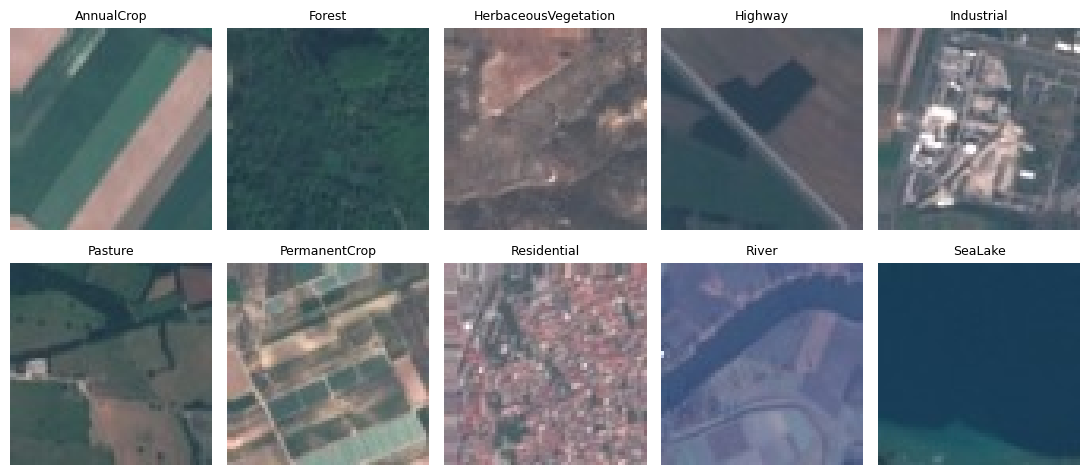

{'AnnualCrop': 400, 'Forest': 400, 'HerbaceousVegetation': 400, 'Highway': 400, 'Industrial': 400, 'Pasture': 400, 'PermanentCrop': 400, 'Residential': 400, 'River': 400, 'SeaLake': 400}


In [2]:
import matplotlib.pyplot as plt
CLASSES = ["AnnualCrop","Forest","HerbaceousVegetation","Highway","Industrial",
           "Pasture","PermanentCrop","Residential","River","SeaLake"]

fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for c, ax in enumerate(axes.flat):
    ax.imshow(X[y == c][0]); ax.set_title(CLASSES[c], fontsize=9); ax.axis('off')
plt.tight_layout(); plt.show()

print({CLASSES[c]: int((y == c).sum()) for c in range(10)})

**Check:** ten readable thumbnails, and 400 images in every class. This is a
   *small* dataset on purpose — that is what makes the competition interesting.

## Step 2 — Make your own validation split

Hold out part of the 12,000 so you can measure yourself. Split it *stratified*
— same class balance in both halves — so the number you get is trustworthy.
This validation set is **yours**; the server's test sets are separate.

In [3]:
import torch

g = torch.Generator().manual_seed(0)
perm = torch.randperm(len(X), generator=g)
n_val = 800   # ~20% held out for validation
val_idx, tr_idx = perm[:n_val], perm[n_val:]

Xtr, ytr = X[tr_idx], y[tr_idx]
Xva, yva = X[val_idx], y[val_idx]
print(len(Xtr), "train", len(Xva), "val")

3200 train 800 val


**Check:** 3,200 train, 800 val.

## Step 3-4 — Convolution, pooling, channels

See the animations on the assignment page. In one paragraph:

- A **convolution** slides a small filter over the image and reuses the same
  weights everywhere, so it looks at neighbourhoods instead of loose pixels.
- **Pooling** (`MaxPool2d(2)`) halves height and width, keeping the strongest
  response in each 2×2 block.
- One filter makes one feature map; a conv layer has many filters, so **depth**
  grows as resolution shrinks. For 64×64, three conv-pool blocks go 64→32→16→8.

Size rule: a `3×3` filter with `padding=1` leaves the height and width unchanged,
which is why every conv below uses `padding=1`.

## Step 5 — Your first CNN

Three conv blocks, then two fully connected layers. Every argument is one you
now understand.

In [4]:
import torch.nn as nn

class Net(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),  nn.BatchNorm2d(32),  nn.ReLU(), nn.MaxPool2d(2),  # 64->32
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(), nn.MaxPool2d(2),  # 32->16
            nn.Conv2d(64,128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),  # 16->8
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(128*8*8, 256), nn.ReLU(), nn.Linear(256, n_classes),
        )
    def forward(self, x):
        return self.classifier(self.features(x))

print(sum(p.numel() for p in Net().parameters()), "parameters")

2193674 parameters


**Check:** about 2.19 million parameters — under the 5M cap.

## Step 6 — Train it

Normalise the bytes, run mini-batches through SGD, watch validation climb.
`MEAN`/`STD` are the channel statistics of the released training split — the
**same numbers must go in `model.py`** so grading preprocesses images the way
you trained.

In [5]:
MEAN = torch.tensor([0.344, 0.382, 0.409]).view(1,3,1,1)
STD  = torch.tensor([0.199, 0.136, 0.117]).view(1,3,1,1)
def prep(A):  # (N,64,64,3) uint8 -> (N,3,64,64) normalised float
    t = torch.from_numpy(A).permute(0,3,1,2).float().div(255)
    return (t - MEAN) / STD

dev = "cuda" if torch.cuda.is_available() else "cpu"
print("training on", dev)
net = Net().to(dev)
opt = torch.optim.SGD(net.parameters(), lr=0.05, momentum=0.9, weight_decay=5e-4)
lossf = nn.CrossEntropyLoss()

Xtr_t = prep(Xtr).to(dev); ytr_t = torch.from_numpy(ytr).to(dev)
Xva_t = prep(Xva).to(dev); yva_t = torch.from_numpy(yva)

hist = []
for epoch in range(15):
    net.train(); perm = torch.randperm(len(Xtr_t), device=dev)
    for i in range(0, len(Xtr_t) - 127, 128):
        idx = perm[i:i+128]
        opt.zero_grad(); lossf(net(Xtr_t[idx]), ytr_t[idx]).backward(); opt.step()
    net.eval()
    with torch.no_grad():
        tr = (net(Xtr_t).argmax(1).cpu() == torch.from_numpy(ytr)).float().mean().item()
        va = (net(Xva_t).argmax(1).cpu() == yva_t).float().mean().item()
    hist.append((tr, va))
    print(f"epoch {epoch+1:2d}  train {tr:.3f}  val {va:.3f}")

training on cuda
epoch  1  train 0.272  val 0.268
epoch  2  train 0.440  val 0.454
epoch  3  train 0.437  val 0.438
epoch  4  train 0.435  val 0.430
epoch  5  train 0.571  val 0.558
epoch  6  train 0.584  val 0.540
epoch  7  train 0.672  val 0.616
epoch  8  train 0.709  val 0.637
epoch  9  train 0.599  val 0.556
epoch 10  train 0.770  val 0.684
epoch 11  train 0.788  val 0.690
epoch 12  train 0.809  val 0.719
epoch 13  train 0.793  val 0.678
epoch 14  train 0.746  val 0.632
epoch 15  train 0.619  val 0.551


**Check:** validation accuracy reaches roughly **0.90** by epoch 15. That is
already enough to submit.

## Step 7 — Read the learning curves

When training accuracy keeps rising but validation flattens, you are
**overfitting**. Plot both and watch the gap.

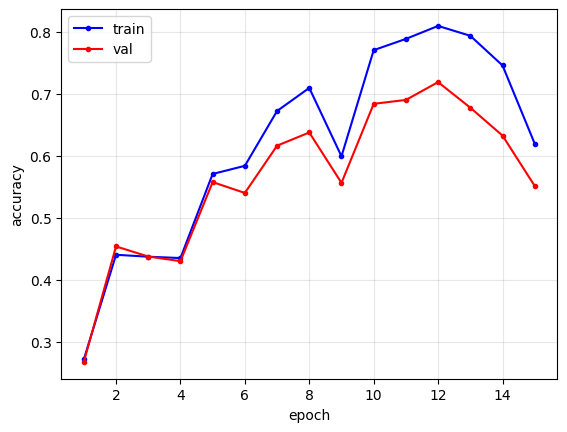

In [6]:
tr = [h[0] for h in hist]; va = [h[1] for h in hist]
ep = range(1, len(hist) + 1)
plt.plot(ep, tr, 'b-o', label='train', markersize=3)
plt.plot(ep, va, 'r-o', label='val',   markersize=3)
plt.xlabel('epoch'); plt.ylabel('accuracy'); plt.legend(); plt.grid(alpha=.3); plt.show()

## Step 8 — Data augmentation

Satellite tiles have **no up**: a rotated or flipped forest is still a forest.
So you can multiply your data for free. This is the highest-value change you
can make. To use it, apply `augment` to each batch inside the training loop
above (`xb = augment(net_input_batch)`), then retrain.

In [7]:
def augment(x):                       # x: (N,3,64,64) on device
    if torch.rand(1).item() < 0.5:
        x = x.flip(3)                # horizontal flip
    k = torch.randint(0, 4, (1,)).item()
    return torch.rot90(x, k, dims=(2,3))   # 0/90/180/270 degrees

## Step 9 — Where to go from here

This is where the tutorial stops handing you code. Roughly in order of payoff:
more augmentation, more epochs with a learning-rate schedule, dropout, a wider
or deeper network (mind the 5M cap). A well-tuned model reaches the mid-90s on
validation. **Use your own val set to decide what actually helps** — not the
public leaderboard.

> **No transfer learning.** Train from scratch on the released data only.
> Pretrained weights (ImageNet, `pretrained=True`, any downloaded model) are
> not allowed, and neither is outside data. Top submissions are re-run on the
> released data with no network access, so a pretrained model cannot reproduce.

## Step 10 — Write `model.py`

The grader imports a class called `Model` and calls three methods. This cell
writes a `model.py` that matches the `Net` above. Two mistakes cost more
students their submission than anything else:

1. **Saving the whole model** instead of the state dict — the grader loads with
   `weights_only=True` and cannot unpickle a whole model object.
2. **Hardcoding the GPU** — the grader runs on CPU. Load with
   `map_location='cpu'` and never call `.cuda()` in `predict`.

In [8]:
model_py = r'''
import torch
import torch.nn as nn

class Net(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),  nn.BatchNorm2d(32),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(128*8*8, 256), nn.ReLU(), nn.Linear(256, n_classes),
        )
    def forward(self, x):
        return self.classifier(self.features(x))

class Model:
    MEAN = torch.tensor([0.344,0.382,0.409]).view(1,3,1,1)
    STD  = torch.tensor([0.199,0.136,0.117]).view(1,3,1,1)
    def __init__(self):
        self.net = Net()
    def load(self, path):
        self.net.load_state_dict(torch.load(path, map_location='cpu', weights_only=True))
        self.net.eval()
    @torch.no_grad()
    def predict(self, x):                      # x: uint8 (N,64,64,3)
        x = x.permute(0,3,1,2).float().div(255)
        x = (x - self.MEAN) / self.STD
        return self.net(x).argmax(1).to(torch.int64)
'''
open("model.py", "w").write(model_py)

# Save the STATE DICT (not the whole model) and a train.py + README.
torch.save(net.to("cpu").state_dict(), "weights.pth")
open("train.py", "w").write("# see the assignment notebook: Steps 5-6 train this model\n")
open("README.md", "w").write("nickname: CHANGE_ME\n\nTutorial CNN, 15 epochs, no augmentation.\n")
print("wrote model.py, weights.pth, train.py, README.md")

wrote model.py, weights.pth, train.py, README.md


> **Edit `README.md`** and set your nickname before submitting. You can also
> change it later on the leaderboard.

## Step 11 — Pre-submission check, then zip

Download the checker and run it. **If it passes here, it passes on the server.**
Then zip the four files.

In [9]:
import urllib.request, zipfile
urllib.request.urlretrieve(f"{BASE}/arena_check.py", "arena_check.py")

with zipfile.ZipFile('submission.zip', 'w', zipfile.ZIP_DEFLATED) as z:
    for f in ['model.py', 'weights.pth', 'train.py', 'README.md']:
        z.write(f)
print("built submission.zip")

built submission.zip


In [10]:
!python arena_check.py submission.zip --images train_images.npy

arena_check  torch 2.11.0+cu128  (GPU hidden on purpose)

[PASS] torch version
         2.11.0+cu128
[PASS] submission structure
         all four files present
[PASS] model.py size
         1.2 KB
[PASS] weights.pth size
         8.8 MB
[PASS] weights load (weights_only=True)
         25 tensors
[PASS] parameter budget
         2,193,674 / 5,000,000
[PASS] model.py imports
         Model with load() and predict() found
[PASS] test images
         100 from train_images.npy
[PASS] Model.load()
[PASS] Model.predict() runs on CPU
         100 images in 0.38s
[PASS] prediction shape
         (100,)
[PASS] prediction range
         0..9
[PASS] prediction dtype
         torch.int64
[PASS] inference speed
         ~11s projected for 3000 images

------------------------------------------------------------
PASSED  all checks, 0 warning(s). This submission will be accepted.


**Check:** the last line reads `PASSED`. If it says `FAILED`, follow the arrows
it prints, fix the offending cell, and rerun.

## Step 12 — Submit

In Colab: **Files** panel (left) → download `submission.zip`. Then sign in to
the Arena with your **UTRGV account**, pick a nickname, and upload it. Your
public score appears within a minute or two. Submit as often as you like.